In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv("../data/X_rf_train.csv")
X_test = pd.read_csv("../data/X_rf_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [5]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
y_train_pred = knn.predict(
    X_train_scaled
)

y_pred = knn.predict(
    X_test_scaled
)

In [9]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [10]:
train_r2 = r2_score(
    y_train,
    y_train_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("Train R2 :", round(train_r2,4))

print("Test R2 :", round(r2,4))

print("MAE :", round(mae,4))

print("RMSE :", round(rmse,4))

Train R2 : 0.965
Test R2 : 0.917
MAE : 0.0687
RMSE : 0.1653


In [11]:
from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=5
    ))
])

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

print(cv_scores)

print()

print(
    "Mean CV R2:",
    round(cv_scores.mean(),4)
)

print(
    "Std CV R2:",
    round(cv_scores.std(),4)
)

[0.95411031 0.89004605 0.9437487  0.90892918 0.94060388 0.93293888
 0.91139915 0.91323534 0.92046878 0.89052183]

Mean CV R2: 0.9206
Std CV R2: 0.0208


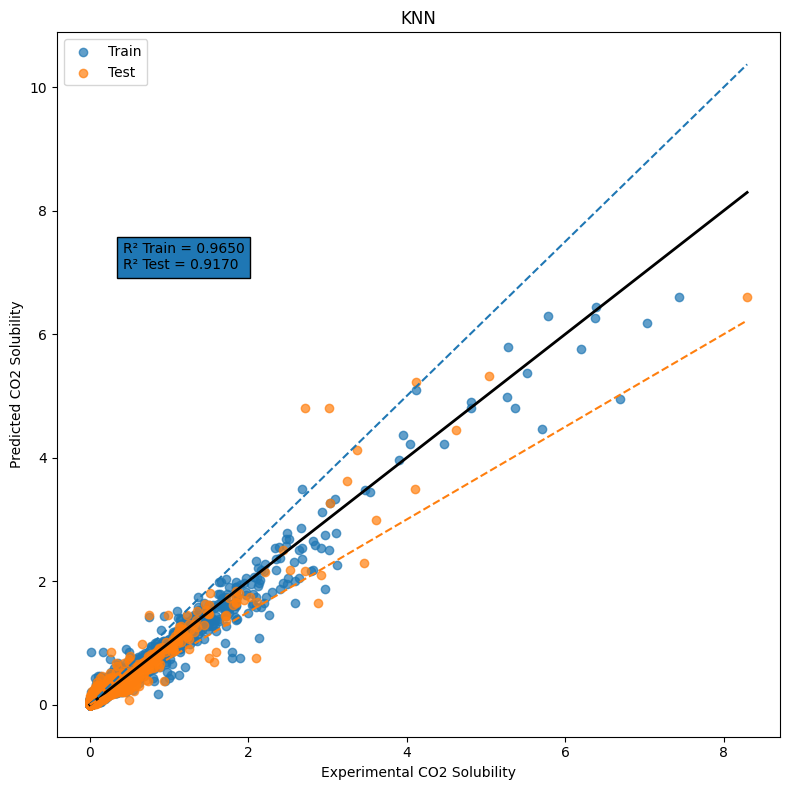

In [12]:
all_values = np.concatenate([
    y_train,
    y_test,
    y_train_pred,
    y_pred
])

xmin = all_values.min()
xmax = all_values.max()

# Perfect prediction line
x_line = np.linspace(xmin, xmax, 100)

# ±25%
upper = x_line * 1.25
lower = x_line * 0.75

plt.figure(figsize=(8,8))

# Train
plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

# Test
plt.scatter(
    y_test,
    y_pred,
    label="Test",
    alpha=0.7
)

# Perfect prediction
plt.plot(
    x_line,
    x_line,
    color="black",
    linewidth=2
)

# +25%
plt.plot(
    x_line,
    upper,
    linestyle="--"
)

# -25%
plt.plot(
    x_line,
    lower,
    linestyle="--"
)

plt.xlabel("Experimental CO2 Solubility")
plt.ylabel("Predicted CO2 Solubility")

plt.legend()

plt.text(
    xmin + 0.05*(xmax-xmin),
    xmax - 0.15*(xmax-xmin),
    f"R² Train = {train_r2:.4f}\nR² Test = {r2:.4f}",
    bbox=dict()
)

plt.title("KNN")

plt.tight_layout()

plt.show()

In [13]:
train_error = y_train - y_train_pred
test_error = y_test - y_pred

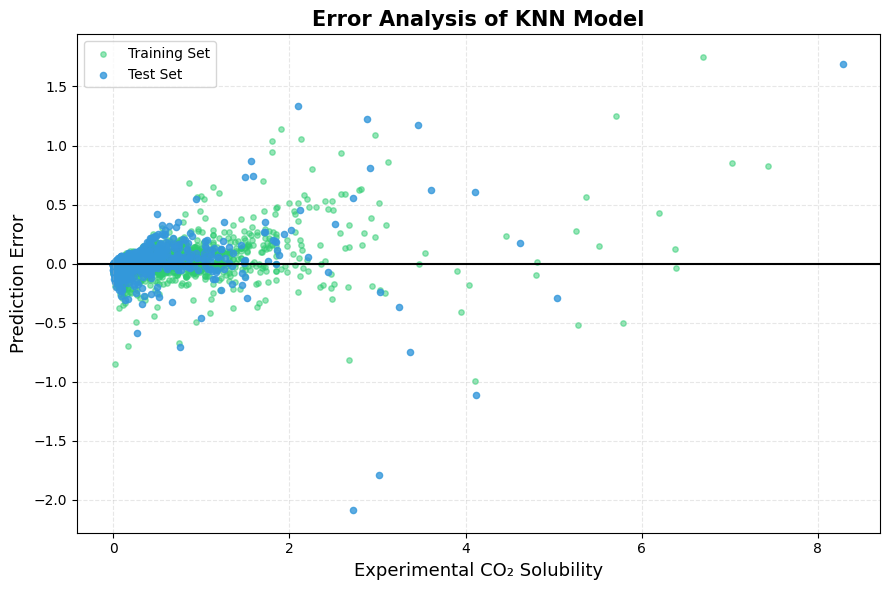

In [32]:
plt.figure(figsize=(9,6))

plt.scatter(
    y_train,
    train_error,
    c="#2ecc71",
    alpha=0.5,
    s=15,
    label="Training Set"
)

plt.scatter(
    y_test,
    test_error,
    c="#3498db",
    alpha=0.8,
    s=20,
    label="Test Set"
)

plt.axhline(
    0,
    color="black",
    linewidth=1.5
)

plt.xlabel(
    "Experimental CO₂ Solubility",
    fontsize=13
)

plt.ylabel(
    "Prediction Error",
    fontsize=13
)

plt.title(
    "Error Analysis of KNN Model",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

In [18]:
train_error = np.array(train_error).flatten()
test_error = np.array(test_error).flatten()

xmin = min(train_error.min(), test_error.min())
xmax = max(train_error.max(), test_error.max())

In [34]:
from scipy.stats import norm

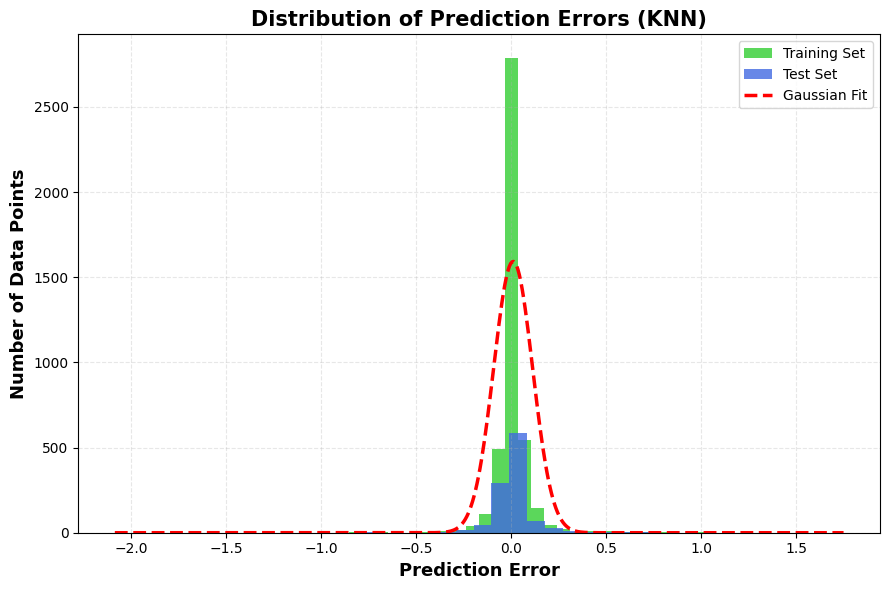

In [36]:
mu_train, sigma_train = norm.fit(train_error)

# Fit Gaussian on test errors
mu_test, sigma_test = norm.fit(test_error)

# Create x values
xmin = min(train_error.min(), test_error.min())
xmax = max(train_error.max(), test_error.max())

x = np.linspace(xmin, xmax, 500)

# Plot
plt.figure(figsize=(9,6))

# Training histogram
plt.hist(
    train_error,
    bins=40,
    color="limegreen",
    alpha=0.8,
    label="Training Set"
)

# Test histogram
plt.hist(
    test_error,
    bins=40,
    color="royalblue",
    alpha=0.8,
    label="Test Set"
)

# Gaussian curves
plt.plot(
    x,
    norm.pdf(x, mu_train, sigma_train) * len(train_error) * (xmax-xmin)/40,
    'r--',
    linewidth=2.5,
    label="Gaussian Fit"
)

plt.xlabel(
    "Prediction Error",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Data Points",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Distribution of Prediction Errors (KNN)",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    fontsize=10
)

plt.grid(
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()

plt.show()

In [20]:
df=pd.read_csv("../data/DataWithDescriptors.csv")
df.columns

Index(['Unnamed: 0', 'IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES',
       'Anion_SMILES', 'Temperature (0 C)', 'Pressure (bar)',
       'CO2 capacity (mol CO2/mol IL)', 'Cation_Family',
       ...
       'An_fr_sulfide', 'An_fr_sulfonamd', 'An_fr_sulfone',
       'An_fr_term_acetylene', 'An_fr_tetrazole', 'An_fr_thiazole',
       'An_fr_thiocyan', 'An_fr_thiophene', 'An_fr_unbrch_alkane',
       'An_fr_urea'],
      dtype='str', length=444)

In [21]:
features=pd.read_excel("../outputs/tables/RF_Top20_Features.xlsx")

In [22]:
rf_features = features.iloc[:,0].tolist()

print(rf_features)
print(len(rf_features))

['Pressure (bar)', 'Temperature (0 C)', 'Cat_MolLogP', 'Cat_EState_VSA2', 'An_TPSA', 'Cat_VSA_EState3', 'An_AvgIpc', 'An_SlogP_VSA1', 'Cat_TPSA', 'Cat_EState_VSA9', 'Cat_BCUT2D_LOGPLOW', 'Cat_NumHDonors', 'Cat_SMR_VSA5', 'Cat_SMR_VSA1', 'Cat_PEOE_VSA1', 'Cat_NHOHCount', 'Cat_EState_VSA8', 'Cat_Chi4v', 'An_BalabanJ', 'An_PEOE_VSA3']
20


In [23]:
ranged_df=df[(df["Temperature (0 C)"] >= 25) &(df["Temperature (0 C)"] <= 30) &(df["Pressure (bar)"] >= 0.5) &(df["Pressure (bar)"] <= 1.5)].copy()

In [24]:
X_ranged = ranged_df[rf_features]

X_ranged_scaled = scaler.transform(X_ranged)

In [26]:
ranged_df["LR_Pred"] = knn.predict(
    X_ranged_scaled
)

In [27]:
rf_ranking = (ranged_df.groupby("IL NAME")["LR_Pred"].mean().reset_index())

In [28]:
top10_rf = rf_ranking.sort_values(by="LR_Pred",ascending=False).head(10)

print(top10_rf)

          IL NAME  LR_Pred
67    [TETAH][Py]  1.60680
66    [TETAH][Im]  1.60680
69    [TETAH][Tz]  1.60680
68    [TETAH][Pz]  1.60680
59  [P66614][Met]  0.98800
58  [P66614][Ile]  0.98800
57  [P66614][Gly]  0.98800
56  [P66614][Ala]  0.98800
62  [P66614][Sar]  0.98800
1     [AmemI][Br]  0.92058


In [37]:
x=df[rf_features]
X_scaled = scaler.transform(x)


In [40]:
y_all_pred = knn.predict(X_scaled)

family_results = pd.DataFrame({
    "Actual": df["CO2 capacity (mol CO2/mol IL)"],
    "Predicted":  y_all_pred.ravel(),
    "Family": df["Cation_Family"].values
})

In [29]:
results = pd.DataFrame({
    "Actual": y_test.values.ravel(),
    "Predicted": y_pred.ravel(),
    "Family": df.loc[
        X_test.index,
        "Cation_Family"
    ].values
})

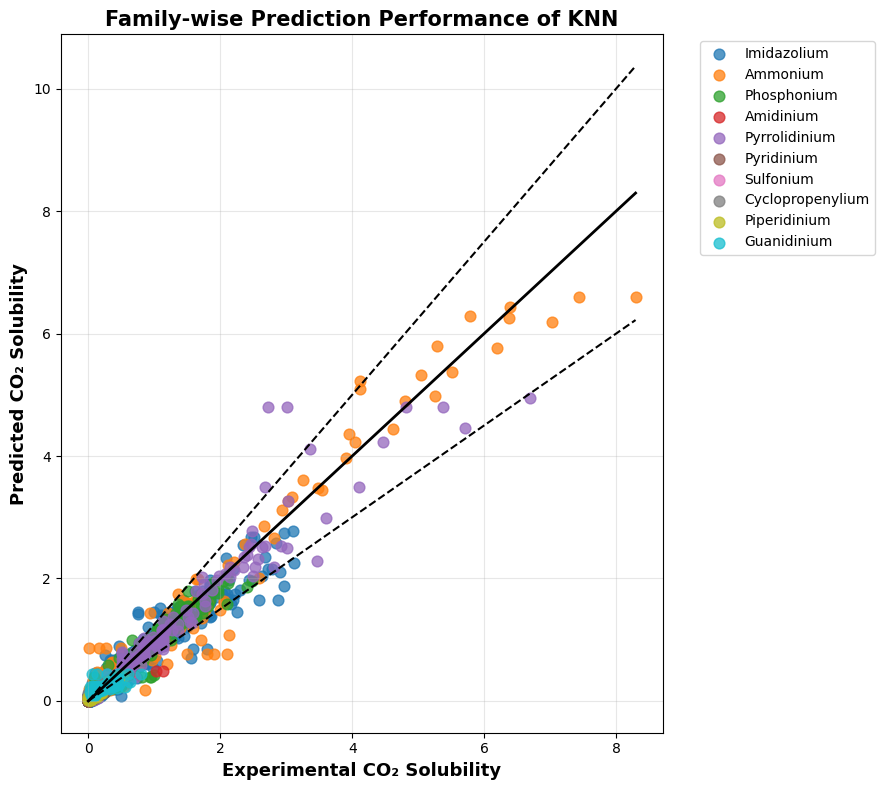

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,8))

families = family_results["Family"].unique()

for family in families:

    temp = family_results[
        family_results["Family"] == family
    ]

    plt.scatter(
        temp["Actual"],
        temp["Predicted"],
        s=60,
        alpha=0.75,
        label=family
    )

# Perfect prediction line
mn = min(
    family_results["Actual"].min(),
    family_results["Predicted"].min()
)

mx = max(
    family_results["Actual"].max(),
    family_results["Predicted"].max()
)

plt.plot(
    [mn,mx],
    [mn,mx],
    color="black",
    linewidth=2
)

# +25%
plt.plot(
    [mn,mx],
    [mn*1.25,mx*1.25],
    "--",
    color="black"
)

# -25%
plt.plot(
    [mn,mx],
    [mn*0.75,mx*0.75],
    "--",
    color="black"
)

plt.xlabel(
    "Experimental CO₂ Solubility",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Predicted CO₂ Solubility",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Family-wise Prediction Performance of KNN",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()